# Medical Insurance Cost Prediction

The objective of this project is to apply supervised machine learning techniques to predict medical insurance costs based on personal attributes such as age, BMI, smoking status, and region.

## Algorithms Used
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
df = pd.read_csv("/content/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.shape

(1338, 7)

Check Missing Values

In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


## Removing Duplicate Records
Duplicate rows are removed to ensure data quality and avoid repeated observations.

In [7]:
df.drop_duplicates(inplace=True)

Data Type Verification

In [8]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


Outlier Detection

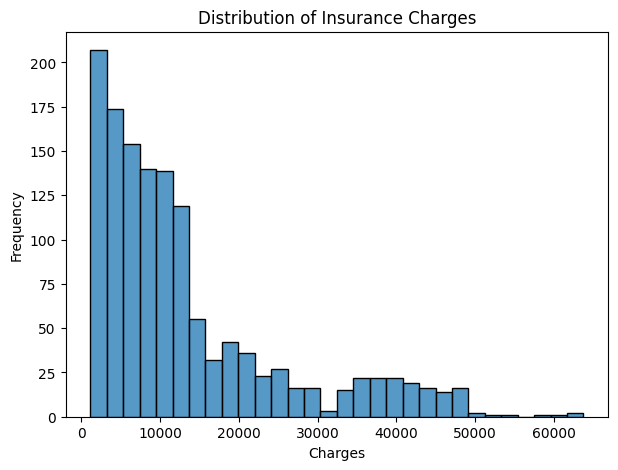

In [10]:
plt.figure(figsize=(7,5))
sns.histplot(df["charges"], bins=30)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

Encode Categorical Variables

In [12]:
encoder = LabelEncoder()

df["sex"] = encoder.fit_transform(df["sex"])
df["smoker"] = encoder.fit_transform(df["smoker"])
df["region"] = encoder.fit_transform(df["region"])

Feature Selection

In [13]:
X = df.drop("charges", axis=1)
y = df["charges"]

## Feature Scaling
Feature scaling is applied using StandardScaler to normalize feature values and improve model performance.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Linear Regression Model

In [16]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

Decision Tree Model

In [17]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

Random Forest Model

In [18]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Model Evaluation Function

In [19]:
def evaluate(actual, predicted):

    r2 = r2_score(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)

    return r2, mse, rmse, mae

Calculate Metrics

In [20]:
lr_results = evaluate(y_test, pred_lr)
dt_results = evaluate(y_test, pred_dt)
rf_results = evaluate(y_test, pred_rf)

print("Linear Regression:", lr_results)
print("Decision Tree:", dt_results)
print("Random Forest:", rf_results)

Linear Regression: (0.8068466322629113, 35493102.61165048, np.float64(5957.608799816457), 4182.353155288295)
Decision Tree: (0.7682549018546077, 42584567.09601559, np.float64(6525.6851821104265), 3029.3844336902985)
Random Forest: (0.8814580310031078, 21782805.646550935, np.float64(4667.205335803315), 2583.074719825)


Model Comparison

In [21]:
comparison = pd.DataFrame({

"Model": ["Linear Regression", "Decision Tree", "Random Forest"],

"R2 Score": [lr_results[0], dt_results[0], rf_results[0]],

"MSE": [lr_results[1], dt_results[1], rf_results[1]],

"RMSE": [lr_results[2], dt_results[2], rf_results[2]],

"MAE": [lr_results[3], dt_results[3], rf_results[3]]

})

comparison

,Model,R2 Score,MSE,RMSE,MAE
0,Linear Regression,0.806847,3.549310e+07,5957.608800,4182.353155
1,Decision Tree,0.768255,4.258457e+07,6525.685182,3029.384434
2,Random Forest,0.881458,2.178281e+07,4667.205336,2583.074720
